In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

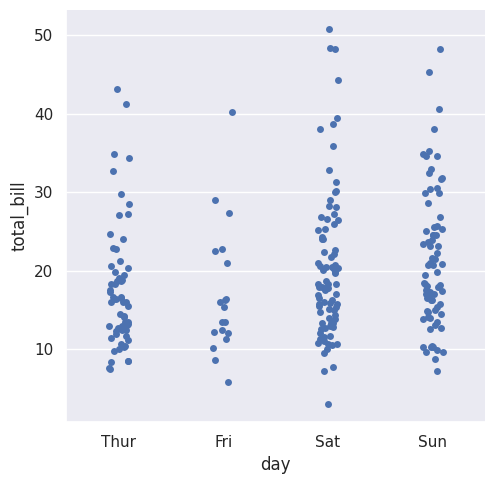

In [2]:
tips = sns.load_dataset("tips")
sns.catplot(data=tips, x="day", y="total_bill")

- The jitter parameter controls the magnitude of jitter or disables it altogether:

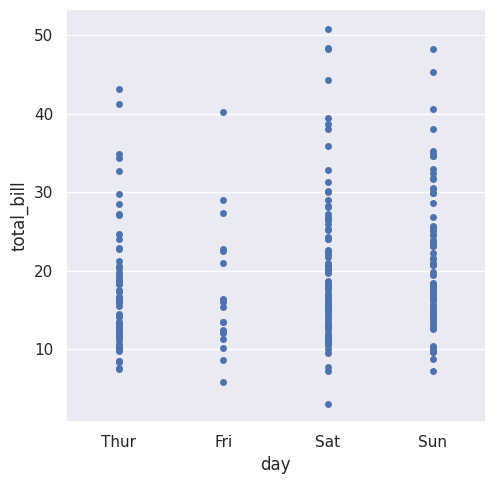

In [3]:
sns.catplot(data=tips, x="day", y="total_bill", jitter=False)

- The second approach adjusts the points along the categorical axis using an algorithm that prevents them from overlapping. It can give a better representation of the distribution of observations, although it only works well for relatively small datasets. This kind of plot is sometimes called a “beeswarm” and is drawn in seaborn by swarmplot(), which is activated by setting kind="swarm" in catplot():

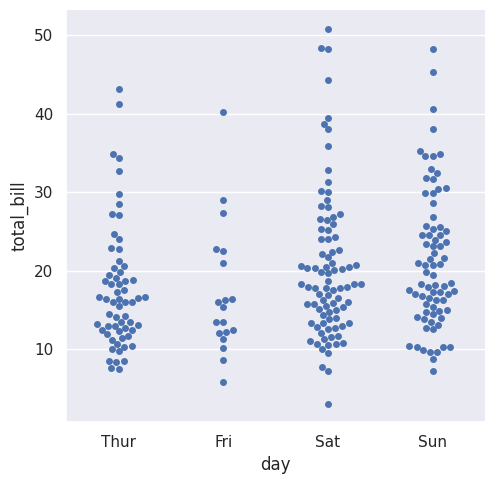

In [5]:
sns.catplot(data=tips, x="day", y="total_bill", kind="swarm")

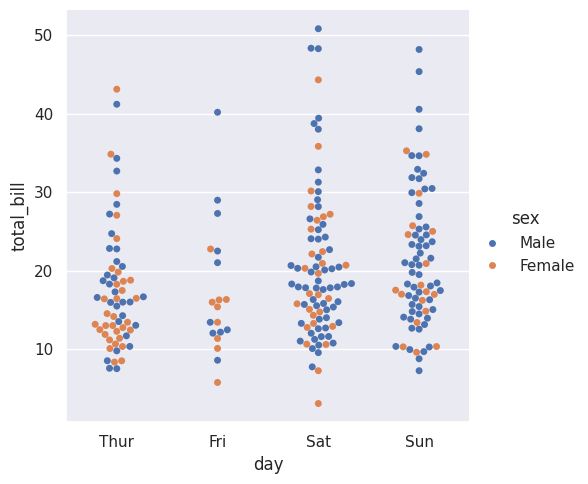

In [6]:
sns.catplot(data=tips, x="day", y="total_bill", hue="sex", kind="swarm")

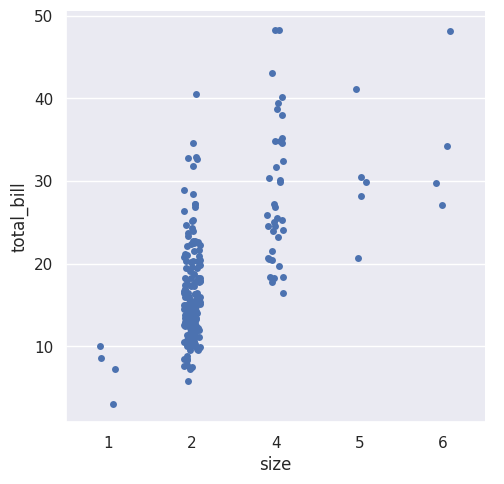

In [7]:
sns.catplot(data=tips.query("size != 3"), x="size", y="total_bill")

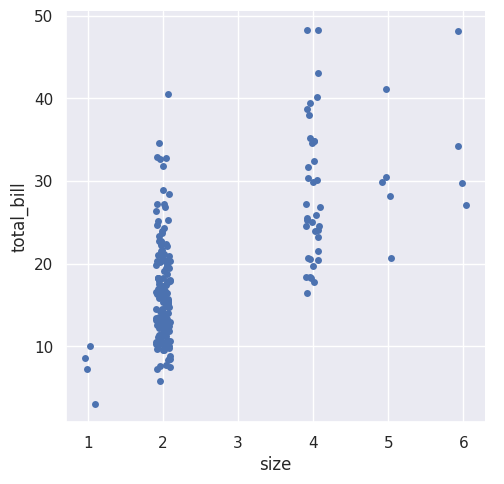

In [8]:
sns.catplot(data=tips.query("size != 3"), x="size", y="total_bill", native_scale=True)

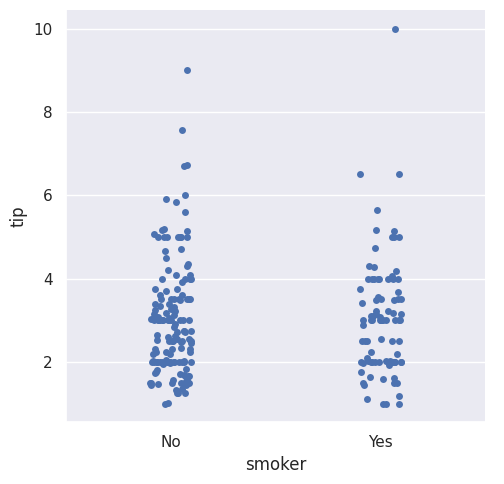

In [9]:
sns.catplot(data=tips, x="smoker", y="tip", order=["No", "Yes"])

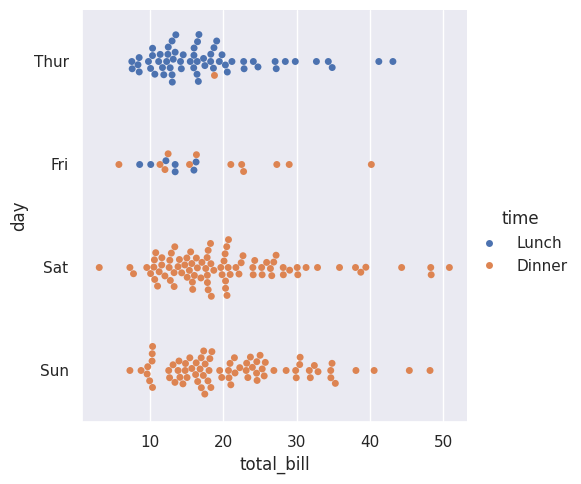

In [10]:
sns.catplot(data=tips, x="total_bill", y="day", hue="time", kind="swarm")

### Comparing Distributions

#### Boxplot

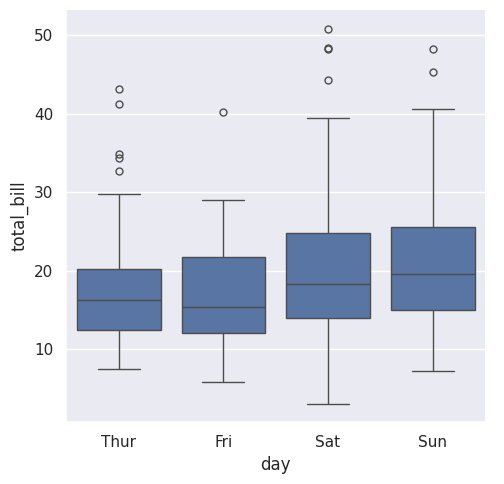

In [11]:
sns.catplot(data=tips, x="day", y="total_bill", kind="box")

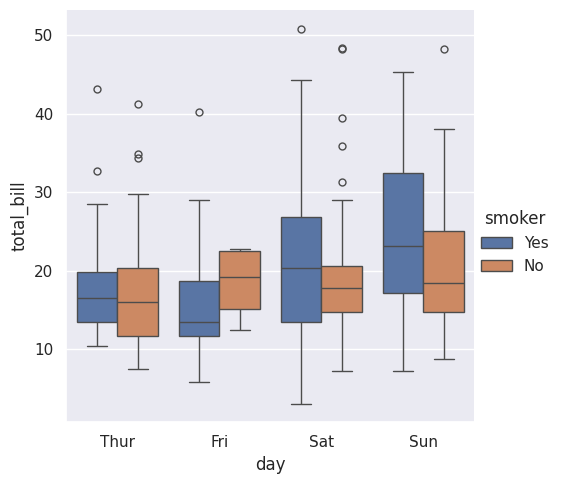

In [12]:
sns.catplot(data=tips, x="day", y="total_bill", hue="smoker", kind="box")

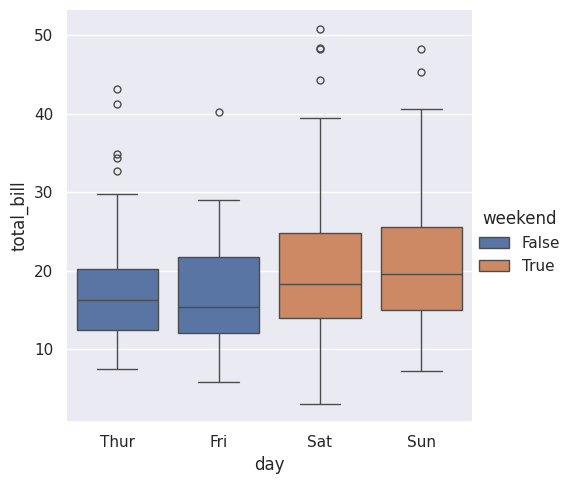

In [13]:
tips["weekend"] = tips["day"].isin(["Sat", "Sun"])
sns.catplot(data=tips, x="day", y="total_bill", hue="weekend", kind="box")

#### Boxenplot

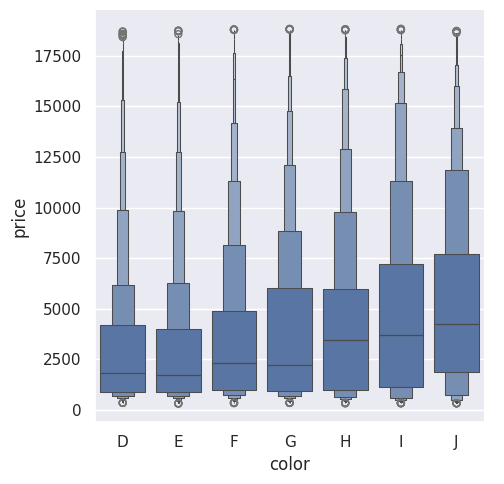

In [14]:
diamonds = sns.load_dataset("diamonds")
sns.catplot(
    data=diamonds.sort_values("color"),
    x="color", y="price", kind="boxen",
)

#### Violinplots

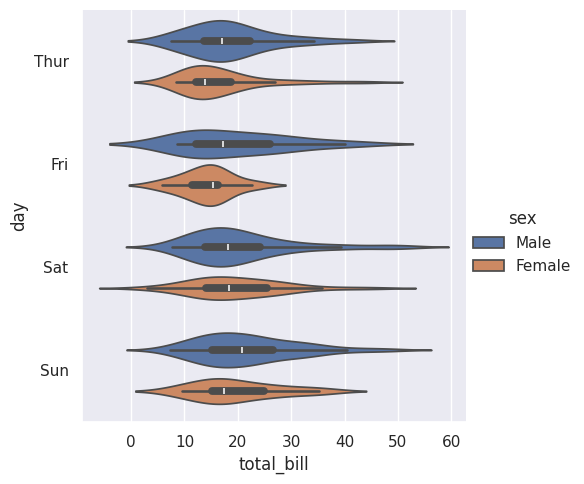

In [15]:
sns.catplot(
    data=tips, x="total_bill", y="day", hue="sex", kind="violin",
)

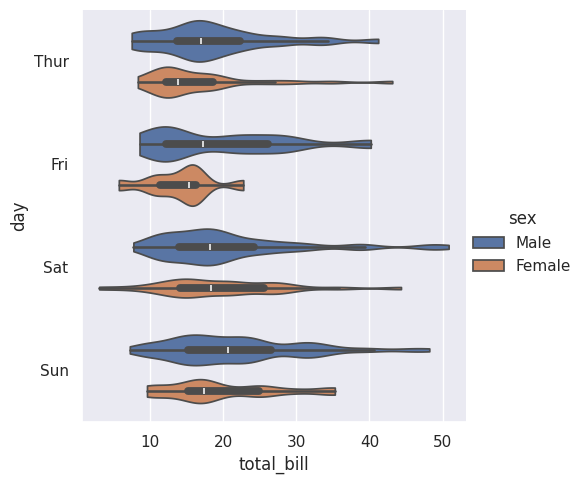

In [16]:
sns.catplot(
    data=tips, x="total_bill", y="day", hue="sex",
    kind="violin", bw_adjust=.5, cut=0,
)

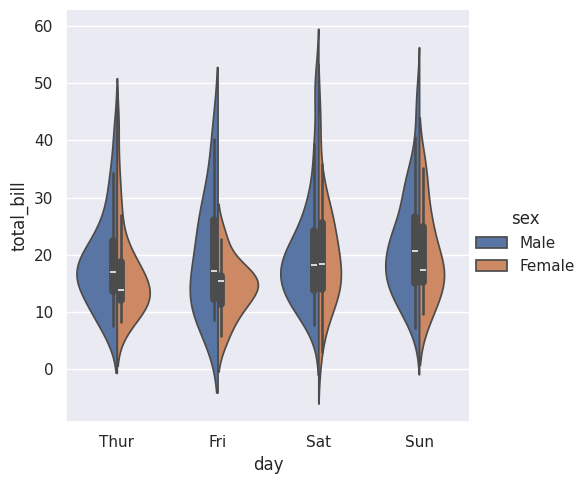

In [17]:
sns.catplot(
    data=tips, x="day", y="total_bill", hue="sex",
    kind="violin", split=True,
)

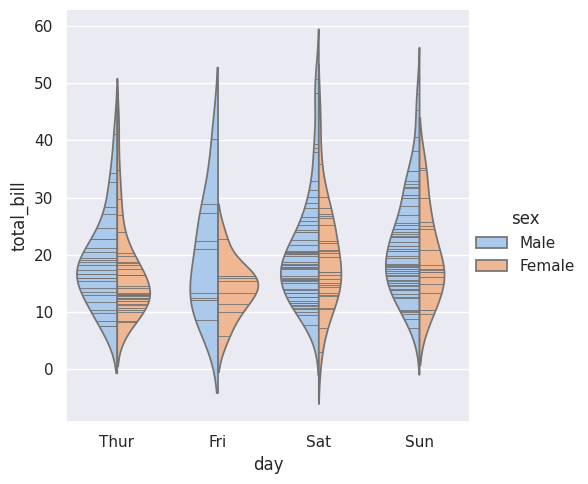

In [18]:
sns.catplot(
    data=tips, x="day", y="total_bill", hue="sex",
    kind="violin", inner="stick", split=True, palette="pastel",
)

<Axes: xlabel='day', ylabel='total_bill'>

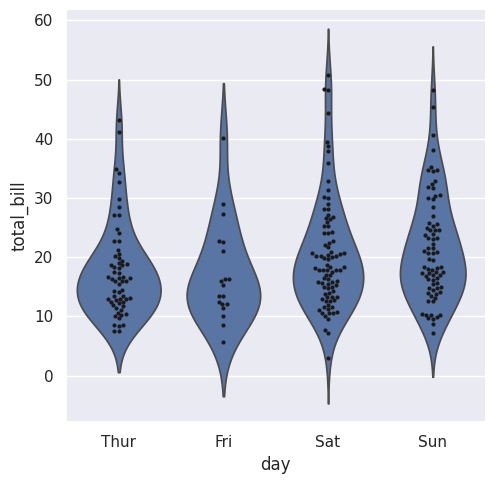

In [19]:
g = sns.catplot(data=tips, x="day", y="total_bill", kind="violin", inner=None)
sns.swarmplot(data=tips, x="day", y="total_bill", color="k", size=3, ax=g.ax)

### Estimating central tendency

- For other applications, rather than showing the distribution within each category, you might want to show an estimate of the central tendency of the values. Seaborn has two main ways to show this information. Importantly, the basic API for these functions is identical to that for the ones discussed above.

#### Bar plots

- A familiar style of plot that accomplishes this goal is a bar plot. In seaborn, the barplot() function operates on a full dataset and applies a function to obtain the estimate (taking the mean by default). When there are multiple observations in each category, it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using error bars:

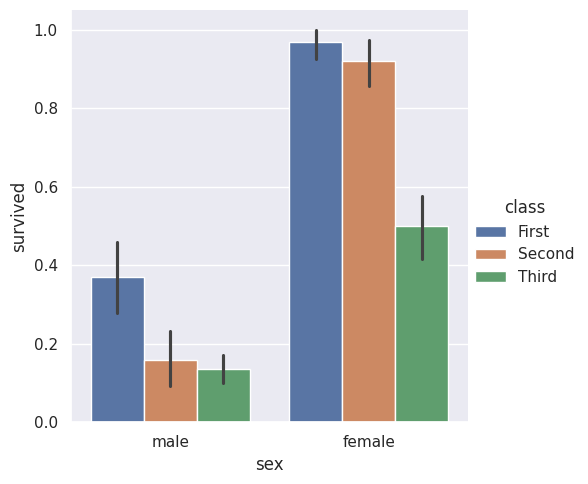

In [20]:
titanic = sns.load_dataset("titanic")
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="bar")

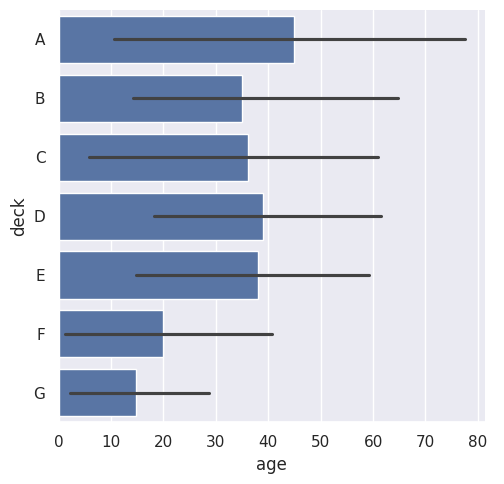

In [21]:
sns.catplot(data=titanic, x="age", y="deck", errorbar=("pi", 95), kind="bar")

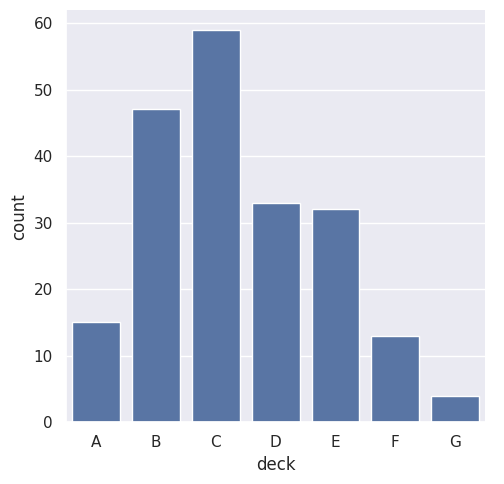

In [22]:
sns.catplot(data=titanic, x="deck", kind="count")

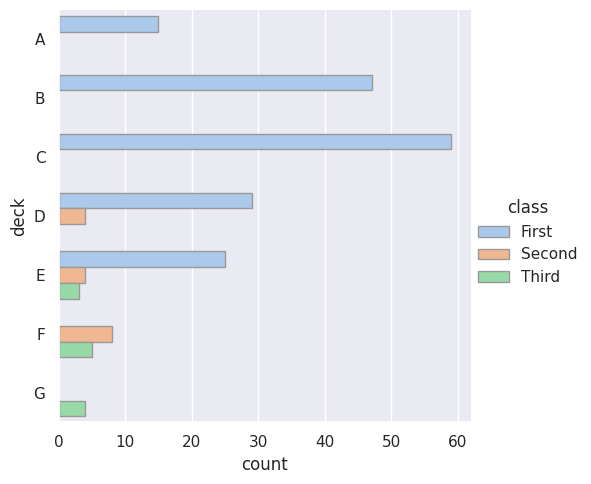

In [23]:
sns.catplot(
    data=titanic, y="deck", hue="class", kind="count",
    palette="pastel", edgecolor=".6",
)

#### Point plots

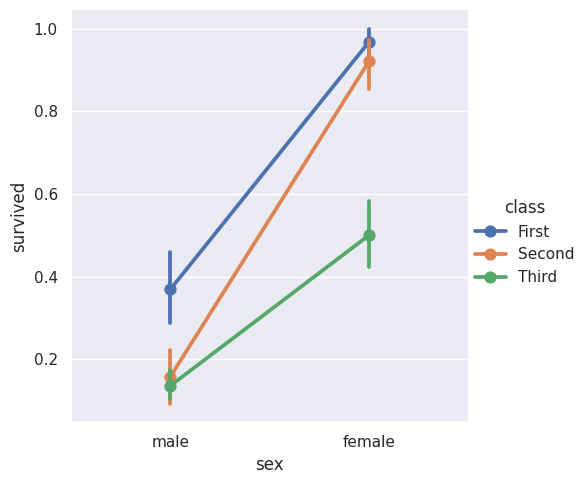

In [24]:
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="point")

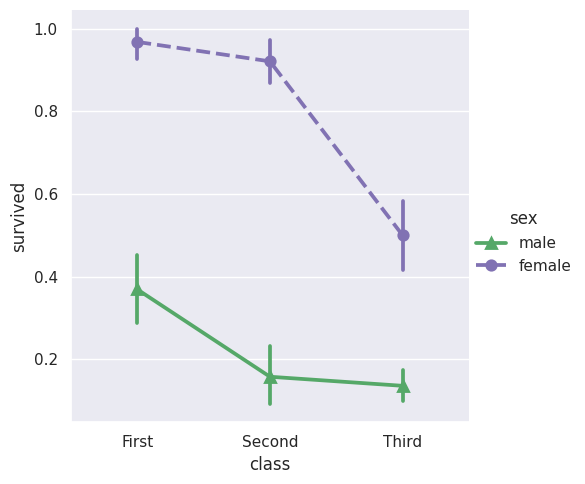

In [25]:
sns.catplot(
    data=titanic, x="class", y="survived", hue="sex",
    palette={"male": "g", "female": "m"},
    markers=["^", "o"], linestyles=["-", "--"],
    kind="point"
)

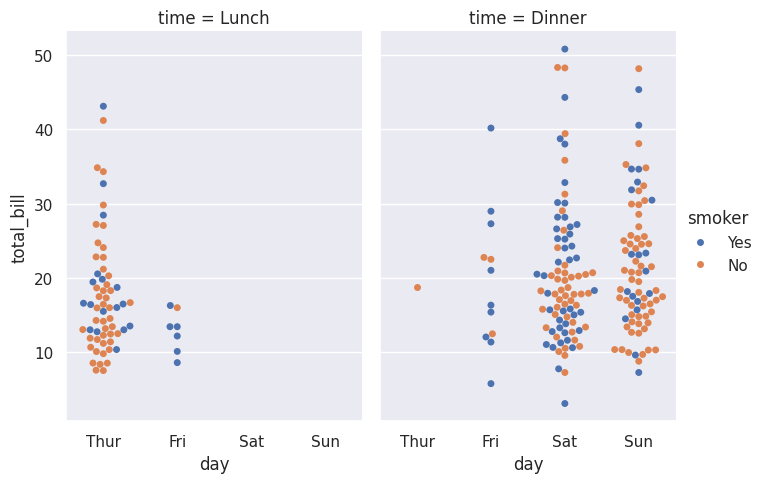

In [26]:
sns.catplot(
    data=tips, x="day", y="total_bill", hue="smoker",
    kind="swarm", col="time", aspect=.7,
)

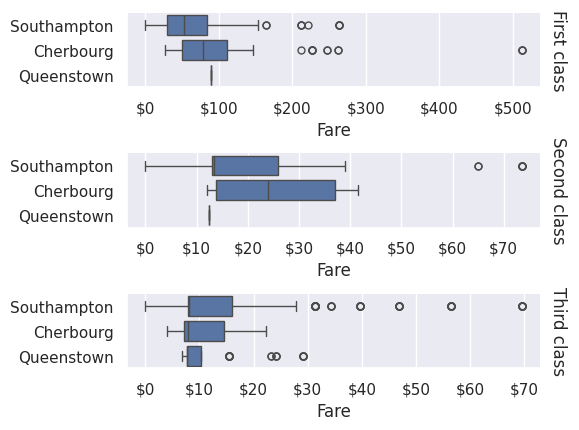

In [27]:
g = sns.catplot(
    data=titanic,
    x="fare", y="embark_town", row="class",
    kind="box", orient="h",
    sharex=False, margin_titles=True,
    height=1.5, aspect=4,
)
g.set(xlabel="Fare", ylabel="")
g.set_titles(row_template="{row_name} class")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter('${x:.0f}')